# Dubins car — Online runtime comparison (all three methods)

## Two metrics

**Metric 1 — Mean per-step compute time [ms]** (all three methods)  
One 'step' = one `solve_mpc()` call (MPC) or one `u_opt(x)` evaluation (Unconstrained).  
Averaged over all converged steps from **successful trajectories only** (double sum):  
`mean_step = ΣΣ step_time[i,j] / Σ n_steps[i]`  where `i ∈ successful trajectories`

**Metric 2 — Mean time-to-reach target [s]** (Vanilla MPC and RA-MPC only)  
Mean simulation duration among successful trajectories.  
Both MPC methods use `dt=0.05 s` → step counts and times are directly comparable.  
Unconstrained omitted (uses `dt=0.02 s`, different convergence behaviour).

**All 300 candidates tested** (seed=42, same pool as other experiments).  
`success_rate = n_reached / 300`  
Sequential execution for accurate per-step wall-clock timing.  
`max_iter=600` for IPOPT (standardised across all experiment notebooks).

In [1]:
import sys, os, time
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)
print('Repo root:', ROOT)

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
import pandas as pd
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed

from sop_bounded_control_dubins_car_result_20260316_211504 import (
    u_opt as u_opt_ra, certificate_opt, k1_opt
)
from sop_bounded_control_unconstrained_controller_20260316_211252 import (
    u_opt as u_opt_unc,
)
u_opt_ra  = sp.Matrix(u_opt_ra)
u_opt_unc = sp.Matrix(u_opt_unc)
cert      = sp.sympify(certificate_opt)

Repo root: c:\IITB\Aalto\Deka\LCSS Revision Experiments\reach_avoid_backstepping_MPC


In [2]:
# ── Symbolic variables & sets ─────────────────────────────────────────────────
x1, x2, th, v = sp.symbols('x1 x2 th v')
y1, y2 = sp.symbols('y1 y2')
state_vars = [x1, x2, th, v]
hx = sp.Matrix([x1, x2])

h_raw        = -(y1**4 + y2**4 - 16)*(y1**4 + y2**4 - 4)
target_set_y = (y2 - 0)**2 + (2*(y1 + 1.7))**2 - 0.4
alpha_coeff  = 1e-3*(-target_set_y + 300)
safe_set_y   = alpha_coeff * h_raw
safe_set_x   = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

safe_set_x_func   = sp.lambdify(state_vars, safe_set_x, 'numpy')
target_set_x_func = sp.lambdify(state_vars, target_set_x, 'numpy')
u1_unc_func       = sp.lambdify(state_vars, u_opt_unc[0], 'numpy')
u2_unc_func       = sp.lambdify(state_vars, u_opt_unc[1], 'numpy')

print('Sets and controller lambdified OK')

Sets and controller lambdified OK


In [3]:
# ── CasADi certificate conversion (for RA-MPC) ────────────────────────────────
def sympy2casadi(expr, sym_map):
    if isinstance(expr, (sp.Integer, sp.Float, sp.Rational,
                         sp.core.numbers.NegativeOne, sp.core.numbers.Half,
                         sp.core.numbers.One, sp.core.numbers.Zero, sp.core.numbers.Pi)):
        return float(expr)
    elif isinstance(expr, sp.Symbol): return sym_map[expr]
    elif isinstance(expr, sp.Add):    return sum(sympy2casadi(a, sym_map) for a in expr.args)
    elif isinstance(expr, sp.Mul):
        r = 1.0
        for a in expr.args: r = r * sympy2casadi(a, sym_map)
        return r
    elif isinstance(expr, sp.Pow):    return sympy2casadi(expr.args[0], sym_map)**sympy2casadi(expr.args[1], sym_map)
    elif isinstance(expr, sp.sin):    return ca.sin(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.cos):    return ca.cos(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.Number): return float(expr)
    else: raise ValueError(f'Unsupported: {type(expr)}')

ca_x1 = ca.SX.sym('x1'); ca_x2 = ca.SX.sym('x2')
ca_th = ca.SX.sym('th'); ca_v  = ca.SX.sym('v')
sym_map = {x1: ca_x1, x2: ca_x2, th: ca_th, v: ca_v}

cert_ca_f     = ca.Function('cert', [ca_x1, ca_x2, ca_th, ca_v],
                             [sympy2casadi(cert, sym_map)])
safe_ca_f_raw = ca.Function('safe', [ca_x1, ca_x2, ca_th, ca_v],
                             [sympy2casadi(safe_set_x, sym_map)])

def cert_vec(xv): return cert_ca_f(xv[0], xv[1], xv[2], xv[3])
def safe_vec(xv): return safe_ca_f_raw(xv[0], xv[1], xv[2], xv[3])

print('CasADi functions built')

CasADi functions built


In [4]:
# ── Shared MPC parameters (same for vanilla and RA-MPC) ───────────────────────
# max_iter=600 standardised across all experiment notebooks
dt_mpc = 0.05
N_hor  = 25
u1_max = 5.0; u2_max = 5.0
TARGET_POS = np.array([-1.7, 0.0])

xc = ca.SX.sym('x', 4); uc = ca.SX.sym('u', 2)
fc = ca.vertcat(xc[3]*ca.cos(xc[2]), xc[3]*ca.sin(xc[2]), uc[0], uc[1])
rhs_ca = ca.Function('f', [xc, uc], [fc])
k1_ = rhs_ca(xc, uc); k2_ = rhs_ca(xc + dt_mpc/2*k1_, uc)
k3_ = rhs_ca(xc + dt_mpc/2*k2_, uc); k4_ = rhs_ca(xc + dt_mpc*k3_, uc)
F_disc = ca.Function('F_disc', [xc, uc],
                     [xc + (dt_mpc/6)*(k1_ + 2*k2_ + 2*k3_ + k4_)])

def h_ca(xv): return ca.vertcat(xv[0], xv[1])
def safe_ca(x):
    y1v, y2v = x[0], x[1]
    h   = -(y1v**4 + y2v**4 - 16)*(y1v**4 + y2v**4 - 4)
    tgt = y2v**2 + (2*(y1v + 1.7))**2 - 0.4
    return 1e-3*(-tgt + 300)*h
def target_ca(x):
    y1v, y2v = x[0], x[1]
    return y2v**2 + (2*(y1v + 1.7))**2 - 0.4

_IPOPT_OPTS = {'ipopt.print_level': 0, 'print_time': 0,
               'ipopt.max_iter': 600, 'ipopt.tol': 1e-4, 'ipopt.acceptable_tol': 1e-3}

def _build_mpc_cost(opti, X, U, N):
    tgt = ca.DM(TARGET_POS)
    Q_y  = ca.DM([[5.,0],[0,5.]]); Qf_y = ca.DM([[80.,0],[0,80.]]); R_u = ca.DM([[.05,0],[0,.05]])
    cost = 0
    for k in range(N):
        dy = h_ca(X[:, k]) - tgt; cost += dy.T@Q_y@dy + U[:, k].T@R_u@U[:, k]
    cost += (h_ca(X[:, N]) - tgt).T @ Qf_y @ (h_ca(X[:, N]) - tgt)
    return cost

def _warm_start(opti, X, U, x0_np, U_warm, N):
    if U_warm is not None:
        U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
        X_ws = np.zeros((4, N+1)); X_ws[:, 0] = x0_np
        for k in range(N):
            xk, uk = X_ws[:, k], U_ws[:, k]
            X_ws[:, k+1] = xk + dt_mpc*np.array(
                [xk[3]*np.cos(xk[2]), xk[3]*np.sin(xk[2]), uk[0], uk[1]])
        opti.set_initial(X, X_ws); opti.set_initial(U, U_ws)
    else:
        tgt_full = np.array([TARGET_POS[0], TARGET_POS[1], x0_np[2], 0.])
        X_ws = np.array([(1-k/N)*x0_np + (k/N)*tgt_full for k in range(N+1)]).T
        opti.set_initial(X, X_ws); opti.set_initial(U, 0)

def solve_vanilla_mpc(x0_val, U_warm=None):
    opti = ca.Opti()
    X = opti.variable(4, N_hor+1); U = opti.variable(2, N_hor)
    x0_np = np.asarray(x0_val, dtype=float).flatten()
    opti.subject_to(X[:, 0] == x0_np)
    for k in range(N_hor):
        opti.subject_to(X[:, k+1] == F_disc(X[:, k], U[:, k]))
        opti.subject_to(safe_ca(X[:, k]) >= 0)
    opti.subject_to(safe_ca(X[:, N_hor]) >= 0)
    opti.subject_to(target_ca(X[:, N_hor]) <= 0)
    opti.subject_to(opti.bounded(-u1_max, U[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U[1, :], u2_max))
    opti.minimize(_build_mpc_cost(opti, X, U, N_hor))
    _warm_start(opti, X, U, x0_np, U_warm, N_hor)
    opti.solver('ipopt', _IPOPT_OPTS)
    try:
        sol = opti.solve(); return True, sol.value(U)
    except Exception: return False, None

def solve_ra_mpc(x0_val, U_warm=None):
    opti = ca.Opti()
    X = opti.variable(4, N_hor+1); U = opti.variable(2, N_hor)
    x0_np = np.asarray(x0_val, dtype=float).flatten()
    opti.subject_to(X[:, 0] == x0_np)
    for k in range(N_hor):
        opti.subject_to(X[:, k+1] == F_disc(X[:, k], U[:, k]))
        opti.subject_to(safe_vec(X[:, k]) >= 0)
    opti.subject_to(safe_vec(X[:, N_hor]) >= 0)
    opti.subject_to(cert_vec(X[:, N_hor]) >= 0)
    opti.subject_to(opti.bounded(-u1_max, U[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U[1, :], u2_max))
    opti.minimize(_build_mpc_cost(opti, X, U, N_hor))
    _warm_start(opti, X, U, x0_np, U_warm, N_hor)
    opti.solver('ipopt', _IPOPT_OPTS)
    try:
        sol = opti.solve(); return True, sol.value(U)
    except Exception: return False, None

print(f'MPC solvers ready: N={N_hor}, dt={dt_mpc}s, max_iter=600')

MPC solvers ready: N=25, dt=0.05s, max_iter=600


In [5]:
# ── All 300 candidates — NO pre-filtering ─────────────────────────────────────
# Same 300 candidates as robustness and sampling-sweep experiments (seed=42).
# success_rate = n_reached / 300 for consistency across all experiments.

N_CANDIDATES = 300
T_max   = 10.0
phi_tol = 0.05

np.random.seed(42)
lower_bound = np.array([-2.0, -2.0, 2*np.pi/3, -1.0])
upper_bound = np.array([ 2.0,  2.0, 4*np.pi/3,  1.0])
x_pool = np.random.rand(4, 1000)*(upper_bound-lower_bound).reshape(-1,1) \
         + lower_bound.reshape(-1,1)

safe_v = np.atleast_1d(np.squeeze(safe_set_x_func(*x_pool)))
tgt_v  = np.atleast_1d(np.squeeze(target_set_x_func(*x_pool)))
cand_idx = np.where((safe_v >= 0) & (tgt_v > 0))[0][:N_CANDIDATES]
x_ic     = x_pool[:, cand_idx]   # shape (4, 300)

print(f'Using all {N_CANDIDATES} candidates (seed=42, no pre-filtering).')
print(f'success_rate = n_reached / {N_CANDIDATES}')

Using all 300 candidates (seed=42, no pre-filtering).
success_rate = n_reached / 300


In [6]:
# ── Timed simulation — Vanilla MPC ───────────────────────────────────────────
# step_times = list of (elapsed_ms, solver_ok) per trajectory.
# Sequential for accurate wall-clock timing.

def simulate_timed_vanilla(x0):
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0; U_prev = None
    step_times = []   # (elapsed_ms, solver_ok)

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0: break

        t0 = time.perf_counter()
        ok, U_opt = solve_vanilla_mpc(x, U_warm=U_prev)
        elapsed_ms = (time.perf_counter() - t0) * 1e3
        step_times.append((elapsed_ms, ok))

        if not ok: break
        u0 = np.array(U_opt[:, 0]).flatten(); U_prev = U_opt

        def rhs(_, x_):
            return [x_[3]*np.cos(x_[2]), x_[3]*np.sin(x_[2]),
                    float(u0[0]), float(u0[1])]
        sol = solve_ivp(rhs, [t, t+dt_mpc], x, method='DOP853',
                        rtol=1e-8, atol=1e-10, max_step=dt_mpc/10)
        if not np.all(np.isfinite(sol.y)): break
        x = sol.y[:, -1]; t += dt_mpc
        xs.append(x.copy()); ts.append(t)

    phi_f   = float(np.squeeze(target_set_x_func(*np.array(xs[-1]))))
    success = phi_f <= phi_tol
    return step_times, success, t

print(f'Running timed Vanilla MPC on all {N_CANDIDATES} candidates ...')
traj_step_times_vanilla = []   # list of (step_times, success, T)
vanilla_results = []
for i in range(N_CANDIDATES):
    stimes, ok, T = simulate_timed_vanilla(x_ic[:, i])
    traj_step_times_vanilla.append((stimes, ok, T))
    vanilla_results.append({
        'traj_id': i, 'success': ok, 'T': T,
        'n_steps':   len(stimes),
        'n_converged': sum(1 for _, sv in stimes if sv),
    })
    if (i+1) % 50 == 0:
        ms_c = [ms for ms, sv in stimes if sv]
        print(f'  [{i+1:3d}/{N_CANDIDATES}] {"OK" if ok else "FAIL"}  T={T:.2f}s  '
              f'mean_conv={np.mean(ms_c):.1f}ms' if ms_c else
              f'  [{i+1:3d}/{N_CANDIDATES}] FAIL  infeasible')

n_ok_v = sum(r['success'] for r in vanilla_results)
print(f'\nVanilla MPC: {n_ok_v}/{N_CANDIDATES} reached ({100*n_ok_v/N_CANDIDATES:.1f}%)')

Running timed Vanilla MPC on all 300 candidates ...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

  [ 50/300] OK  T=1.25s  mean_conv=166.9ms
  [100/300] OK  T=0.40s  mean_conv=148.1ms
  [150/300] OK  T=1.05s  mean_conv=127.0ms
  [200/300] OK  T=0.85s  mean_conv=132.8ms
  [250/300] OK  T=0.45s  mean_conv=137.7ms
  [300/300] OK  T=1.05s  mean_conv=118.9ms

Vanilla MPC: 231/300 reached (77.0%)


In [7]:
# ── Timed simulation — RA-MPC ─────────────────────────────────────────────────
def simulate_timed_ra(x0):
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0; U_prev = None
    step_times = []

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0: break

        t0 = time.perf_counter()
        ok, U_opt = solve_ra_mpc(x, U_warm=U_prev)
        elapsed_ms = (time.perf_counter() - t0) * 1e3
        step_times.append((elapsed_ms, ok))

        if not ok: break
        u0 = np.array(U_opt[:, 0]).flatten(); U_prev = U_opt

        def rhs(_, x_):
            return [x_[3]*np.cos(x_[2]), x_[3]*np.sin(x_[2]),
                    float(u0[0]), float(u0[1])]
        sol = solve_ivp(rhs, [t, t+dt_mpc], x, method='DOP853',
                        rtol=1e-8, atol=1e-10, max_step=dt_mpc/10)
        if not np.all(np.isfinite(sol.y)): break
        x = sol.y[:, -1]; t += dt_mpc
        xs.append(x.copy()); ts.append(t)

    phi_f   = float(np.squeeze(target_set_x_func(*np.array(xs[-1]))))
    success = phi_f <= phi_tol
    return step_times, success, t

print(f'Running timed RA-MPC on all {N_CANDIDATES} candidates ...')
traj_step_times_ra = []
ra_results = []
for i in range(N_CANDIDATES):
    stimes, ok, T = simulate_timed_ra(x_ic[:, i])
    traj_step_times_ra.append((stimes, ok, T))
    ra_results.append({
        'traj_id': i, 'success': ok, 'T': T,
        'n_steps':     len(stimes),
        'n_converged': sum(1 for _, sv in stimes if sv),
    })
    if (i+1) % 50 == 0:
        ms_c = [ms for ms, sv in stimes if sv]
        print(f'  [{i+1:3d}/{N_CANDIDATES}] {"OK" if ok else "FAIL"}  T={T:.2f}s  '
              f'mean_conv={np.mean(ms_c):.1f}ms' if ms_c else
              f'  [{i+1:3d}/{N_CANDIDATES}] FAIL  infeasible')

n_ok_r = sum(r['success'] for r in ra_results)
print(f'\nRA-MPC: {n_ok_r}/{N_CANDIDATES} reached ({100*n_ok_r/N_CANDIDATES:.1f}%)')

Running timed RA-MPC on all 300 candidates ...
  [ 50/300] OK  T=1.25s  mean_conv=114.1ms
  [100/300] OK  T=0.40s  mean_conv=182.5ms
  [150/300] OK  T=1.05s  mean_conv=141.0ms
  [200/300] OK  T=0.85s  mean_conv=140.6ms
  [250/300] OK  T=0.45s  mean_conv=91.9ms
  [300/300] OK  T=1.05s  mean_conv=101.4ms

RA-MPC: 259/300 reached (86.3%)


In [8]:
# ── Timed simulation — Unconstrained controller ───────────────────────────────
# One 'step' = one u_opt(x) evaluation (two polynomial lookups: u1, u2).
# Polynomial evaluation always succeeds — no solver_ok flag needed.
# dt_unc = 0.02 s (original notebook value).
dt_unc = 0.02

def simulate_timed_unconstrained(x0):
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0
    step_times_ms = []

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0: break

        # Time only the polynomial evaluation (complete control computation)
        t0 = time.perf_counter()
        u1_val = float(np.squeeze(u1_unc_func(*x)))
        u2_val = float(np.squeeze(u2_unc_func(*x)))
        elapsed_ms = (time.perf_counter() - t0) * 1e3
        step_times_ms.append(elapsed_ms)

        def rhs(_, x_):
            u1 = float(np.squeeze(u1_unc_func(*x_)))
            u2 = float(np.squeeze(u2_unc_func(*x_)))
            dxdt = np.array([x_[3]*np.cos(x_[2]), x_[3]*np.sin(x_[2]), u1, u2])
            return dxdt if np.all(np.isfinite(dxdt)) else np.zeros(4)

        sol = solve_ivp(rhs, [t, t+dt_unc], x, method='DOP853',
                        rtol=1e-8, atol=1e-10, max_step=dt_unc/5)
        if sol.status < 0 or not np.all(np.isfinite(sol.y)): break
        x = sol.y[:, -1]; t += dt_unc
        xs.append(x.copy()); ts.append(t)

    phi_f   = float(np.squeeze(target_set_x_func(*np.array(xs[-1]))))
    success = phi_f <= phi_tol
    return step_times_ms, success, t

print(f'Running timed Unconstrained on all {N_CANDIDATES} candidates ...')
traj_step_times_unc = []
unc_results = []
for i in range(N_CANDIDATES):
    stimes, ok, T = simulate_timed_unconstrained(x_ic[:, i])
    traj_step_times_unc.append((stimes, ok, T))
    unc_results.append({
        'traj_id': i, 'success': ok, 'T': T,
        'n_steps':     len(stimes),
        'n_converged': len(stimes),
    })
    if (i+1) % 50 == 0:
        print(f'  [{i+1:3d}/{N_CANDIDATES}] {"OK" if ok else "FAIL"}  '
              f'T={T:.2f}s  mean={np.mean(stimes)*1e3:.2f}us')

n_ok_u = sum(r['success'] for r in unc_results)
print(f'\nUnconstrained: {n_ok_u}/{N_CANDIDATES} reached ({100*n_ok_u/N_CANDIDATES:.1f}%)')

Running timed Unconstrained on all 300 candidates ...
  [ 50/300] FAIL  T=10.00s  mean=129.56us
  [100/300] FAIL  T=10.00s  mean=131.71us
  [150/300] FAIL  T=10.00s  mean=121.31us
  [200/300] OK  T=4.06s  mean=129.43us
  [250/300] OK  T=1.76s  mean=112.34us
  [300/300] FAIL  T=10.00s  mean=131.04us

Unconstrained: 100/300 reached (33.3%)


In [9]:
# ── Compute the two metrics ────────────────────────────────────────────────────
#
# METRIC 1: Mean per-step compute time [ms]  (all three methods)
#   Formula: mean over all converged steps from SUCCESSFUL trajectories only
#   ΣΣ step_time[i,j]  /  Σ n_converged[i]   where i ∈ successful trajectories
#   For MPC: 'step' = one solve_mpc() call.  For Unconstrained: one u_opt(x) eval.
#
# METRIC 2: Mean time-to-reach [s]  (Vanilla MPC and RA-MPC only)
#   Both use dt=0.05s so step counts and times are directly comparable.
#   Unconstrained omitted: uses dt=0.02s (different scale).

# Metric 1 arrays: pool converged steps from SUCCESSFUL trajectories only
m1_v = np.array([
    ms for stimes, ok, T in traj_step_times_vanilla
    if ok
    for ms, sv in stimes if sv
])
m1_r = np.array([
    ms for stimes, ok, T in traj_step_times_ra
    if ok
    for ms, sv in stimes if sv
])
m1_u = np.array([
    ms for stimes, ok, T in traj_step_times_unc
    if ok
    for ms in stimes     # all steps converge for unconstrained
])

# Metric 2: time-to-reach for successful MPC trajectories
m2_v = np.array([T for _, ok, T in traj_step_times_vanilla if ok])
m2_r = np.array([T for _, ok, T in traj_step_times_ra      if ok])

print('=' * 72)
print(f'TIMING SUMMARY  ({N_CANDIDATES} candidates each, successful trajectories only)')
print('=' * 72)

print(f'\nMETRIC 1 — Mean per-step compute time [ms]')
print(f'  (one step = one solve_mpc() or one u_opt(x) eval)')
print(f'  (double sum: ΣΣ step_time[i,j] / Σ n_steps[i], i in successful trajs)\n')
hdr = f'  {"Method":<20} {"n_reached":>10} {"total_steps":>12} {"mean [ms]":>10} {"std [ms]":>9} {"median [ms]":>12} {"max [ms]":>10}'
print(hdr); print('  ' + '-'*(len(hdr)-2))
for name, arr, n_ok in [
    ('Vanilla MPC',   m1_v, sum(r['success'] for r in vanilla_results)),
    ('RA-MPC',        m1_r, sum(r['success'] for r in ra_results)),
    ('Unconstrained', m1_u, sum(r['success'] for r in unc_results)),
]:
    print(f'  {name:<20} {n_ok:>10} {len(arr):>12} '
          f'{arr.mean():>10.3f} {arr.std():>9.3f} '
          f'{np.median(arr):>12.3f} {arr.max():>10.3f}')

print(f'\nSpeedup: Unconstrained vs Vanilla MPC = {m1_v.mean()/m1_u.mean():.0f}x faster per step')
print(f'Speedup: Unconstrained vs RA-MPC      = {m1_r.mean()/m1_u.mean():.0f}x faster per step')
print(f'RA-MPC vs Vanilla MPC ratio           = {m1_r.mean()/m1_v.mean():.2f}x')

print(f'\nMETRIC 2 — Mean time-to-reach [s]  (MPC methods, dt={dt_mpc}s each)\n')
hdr2 = f'  {"Method":<20} {"n_reached":>10} {"mean T [s]":>11} {"std T [s]":>10} {"min T [s]":>10} {"max T [s]":>10}'
print(hdr2); print('  ' + '-'*(len(hdr2)-2))
for name, arr, n_ok in [
    ('Vanilla MPC', m2_v, sum(r['success'] for r in vanilla_results)),
    ('RA-MPC',      m2_r, sum(r['success'] for r in ra_results)),
]:
    print(f'  {name:<20} {n_ok:>10} '
          f'{arr.mean():>11.3f} {arr.std():>10.3f} '
          f'{arr.min():>10.3f} {arr.max():>10.3f}')
print('\n  (Unconstrained omitted: uses dt=0.02s, success rate differs)')

TIMING SUMMARY  (300 candidates each, successful trajectories only)

METRIC 1 — Mean per-step compute time [ms]
  (one step = one solve_mpc() or one u_opt(x) eval)
  (double sum: ΣΣ step_time[i,j] / Σ n_steps[i], i in successful trajs)

  Method                n_reached  total_steps  mean [ms]  std [ms]  median [ms]   max [ms]
  -----------------------------------------------------------------------------------------
  Vanilla MPC                 231         4220    165.310    60.567      161.436    903.694
  RA-MPC                      259         5089    120.477    44.333      115.677   1148.106
  Unconstrained               100        27476      0.148     0.076        0.112      0.868

Speedup: Unconstrained vs Vanilla MPC = 1116x faster per step
Speedup: Unconstrained vs RA-MPC      = 813x faster per step
RA-MPC vs Vanilla MPC ratio           = 0.73x

METRIC 2 — Mean time-to-reach [s]  (MPC methods, dt=0.05s each)

  Method                n_reached  mean T [s]  std T [s]  min T [s]

In [10]:
# ── Save CSVs ─────────────────────────────────────────────────────────────────
pd.DataFrame({'step_time_ms': m1_v, 'method': 'Vanilla MPC'}).to_csv(
    'timing_raw_vanilla_mpc.csv', index=False)
pd.DataFrame({'step_time_ms': m1_r, 'method': 'RA-MPC'}).to_csv(
    'timing_raw_ra_mpc.csv', index=False)
pd.DataFrame({'step_time_ms': m1_u, 'method': 'Unconstrained'}).to_csv(
    'timing_raw_unconstrained.csv', index=False)

rows = []
for name, m1_arr, m2_arr, n_ok in [
    ('Vanilla MPC',   m1_v, m2_v, sum(r['success'] for r in vanilla_results)),
    ('RA-MPC',        m1_r, m2_r, sum(r['success'] for r in ra_results)),
    ('Unconstrained', m1_u, None, sum(r['success'] for r in unc_results)),
]:
    rows.append({
        'method':               name,
        'n_reached':            n_ok,
        'success_rate_300_pct': round(100*n_ok/N_CANDIDATES, 1),
        'm1_total_steps':       len(m1_arr),
        'm1_mean_ms':           round(float(m1_arr.mean()), 3),
        'm1_median_ms':         round(float(np.median(m1_arr)), 3),
        'm1_std_ms':            round(float(m1_arr.std()), 3),
        'm1_max_ms':            round(float(m1_arr.max()), 3),
        'm2_mean_T_s':          round(float(m2_arr.mean()), 3) if m2_arr is not None else float('nan'),
        'm2_std_T_s':           round(float(m2_arr.std()),  3) if m2_arr is not None else float('nan'),
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv('timing_summary.csv', index=False)
print('Saved timing CSVs.')
print(summary_df.to_string(index=False))

Saved timing CSVs.
       method  n_reached  success_rate_300_pct  m1_total_steps  m1_mean_ms  m1_median_ms  m1_std_ms  m1_max_ms  m2_mean_T_s  m2_std_T_s
  Vanilla MPC        231                  77.0            4220     165.310       161.436     60.567    903.694        0.913       0.314
       RA-MPC        259                  86.3            5089     120.477       115.677     44.333   1148.106        0.982       0.354
Unconstrained        100                  33.3           27476       0.148         0.112      0.076      0.868          NaN         NaN


C:\Users\nisha\AppData\Local\Temp\ipykernel_17700\4169793915.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(m1_arrs, labels=methods3, patch_artist=True,


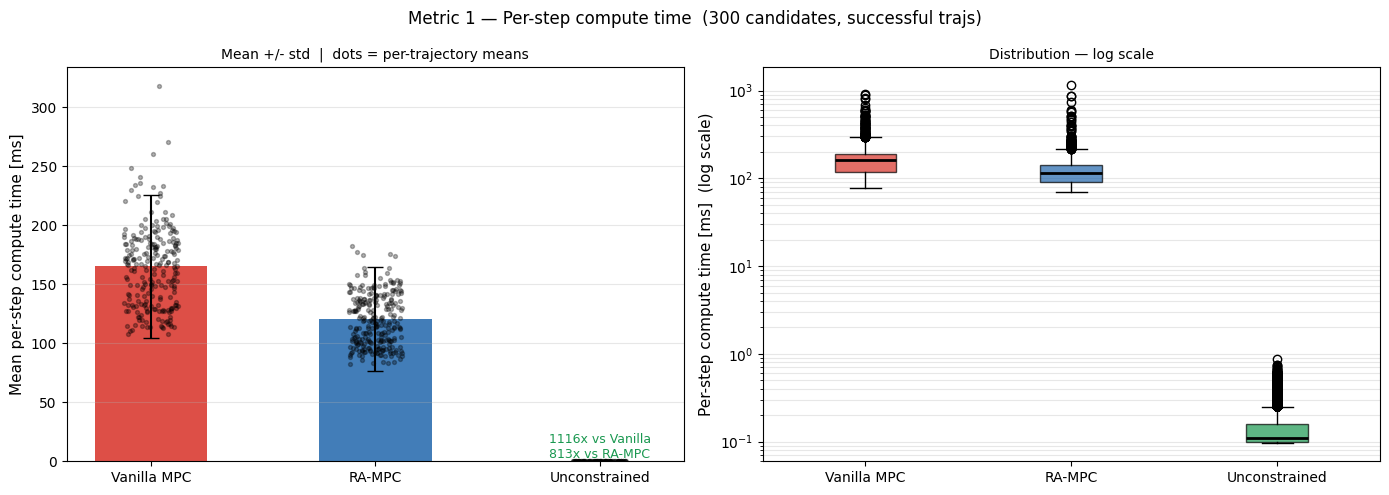

Saved fig_timing_metric1_step_time.png


In [11]:
# ── Figure: Metric 1 — per-step compute time ──────────────────────────────────
methods3 = ['Vanilla MPC', 'RA-MPC', 'Unconstrained']
m1_arrs  = [m1_v, m1_r, m1_u]
col3     = ['#d73027', '#2166ac', '#1a9850']
n_ok3    = [sum(r['success'] for r in vanilla_results),
            sum(r['success'] for r in ra_results),
            sum(r['success'] for r in unc_results)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Metric 1 — Per-step compute time  ({N_CANDIDATES} candidates, successful trajs)',
             fontsize=12)

# Left: bar (mean +/- std) + per-trajectory mean dots
ax = axes[0]
ax.bar(methods3, [a.mean() for a in m1_arrs], yerr=[a.std() for a in m1_arrs],
       capsize=6, color=col3, alpha=0.85, width=0.5)

all_traj_data = [traj_step_times_vanilla, traj_step_times_ra, traj_step_times_unc]
for j, (traj_data, col) in enumerate(zip(all_traj_data, col3)):
    traj_means = []
    for stimes, ok, T in traj_data:
        if not ok: continue
        if stimes and isinstance(stimes[0], tuple):
            ms_c = [ms for ms, sv in stimes if sv]
        else:
            ms_c = list(stimes)
        if ms_c:
            traj_means.append(np.mean(ms_c))
    if traj_means:
        jitter = np.random.default_rng(j).uniform(-0.12, 0.12, len(traj_means))
        ax.scatter(np.full(len(traj_means), j) + jitter, traj_means,
                   color='black', s=8, alpha=0.3, zorder=5)

# Annotate speedup on the Unconstrained bar
sv = m1_v.mean() / m1_u.mean()
sr = m1_r.mean() / m1_u.mean()
ax.text(2, m1_u.mean() + m1_u.std() + 0.3,
        f'{sv:.0f}x vs Vanilla\n{sr:.0f}x vs RA-MPC',
        ha='center', va='bottom', fontsize=9, color='#1a9850')
ax.set_ylabel('Mean per-step compute time [ms]', fontsize=11)
ax.set_title('Mean +/- std  |  dots = per-trajectory means', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Right: log-scale box plot
bp = axes[1].boxplot(m1_arrs, labels=methods3, patch_artist=True,
                     medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], col3):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_yscale('log')
axes[1].set_ylabel('Per-step compute time [ms]  (log scale)', fontsize=11)
axes[1].set_title('Distribution — log scale', fontsize=10)
axes[1].grid(axis='y', alpha=0.3, which='both')

for ax in axes: ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig('fig_timing_metric1_step_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_timing_metric1_step_time.png')

C:\Users\nisha\AppData\Local\Temp\ipykernel_17700\2332868066.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(m2_arrs, labels=methods2, patch_artist=True,


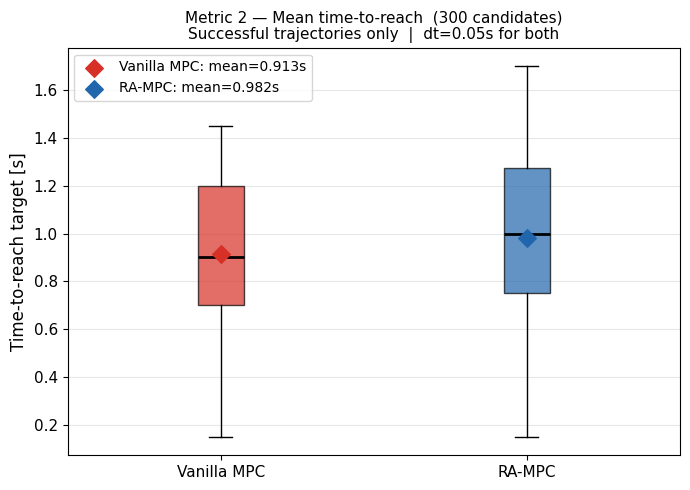

Saved fig_timing_metric2_time_to_reach.png

=== Final answer ===
Metric 1 — Mean per-step compute time (from successful trajectories):
  Vanilla MPC         : 165.310 ms   (n=231/300 reached)
  RA-MPC              : 120.477 ms   (n=259/300 reached)
  Unconstrained       : 0.148 ms   (n=100/300 reached)

Metric 2 — Mean time-to-reach [s] (MPC only, successful trajectories):
  Vanilla MPC         : 0.913 +/- 0.314 s
  RA-MPC              : 0.982 +/- 0.354 s


In [12]:
# ── Figure: Metric 2 — time-to-reach (MPC only) ───────────────────────────────
methods2 = ['Vanilla MPC', 'RA-MPC']
m2_arrs  = [m2_v, m2_r]
col2     = ['#d73027', '#2166ac']

fig, ax = plt.subplots(figsize=(7, 5))
bp2 = ax.boxplot(m2_arrs, labels=methods2, patch_artist=True,
                 medianprops=dict(color='black', lw=2))
for patch, c in zip(bp2['boxes'], col2):
    patch.set_facecolor(c); patch.set_alpha(0.7)

# Overlay mean as diamond
for j, (arr, c, name) in enumerate(zip(m2_arrs, col2, methods2)):
    ax.scatter([j+1], [arr.mean()], marker='D', s=80, color=c, zorder=10,
               label=f'{name}: mean={arr.mean():.3f}s')

ax.set_ylabel('Time-to-reach target [s]', fontsize=12)
ax.set_title(f'Metric 2 — Mean time-to-reach  ({N_CANDIDATES} candidates)\n'
             f'Successful trajectories only  |  dt={dt_mpc}s for both', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig('fig_timing_metric2_time_to_reach.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_timing_metric2_time_to_reach.png')

print(f'\n=== Final answer ===')
print(f'Metric 1 — Mean per-step compute time (from successful trajectories):')
for name, arr, n_ok in zip(methods3, m1_arrs, n_ok3):
    print(f'  {name:<20}: {arr.mean():.3f} ms   (n={n_ok}/{N_CANDIDATES} reached)')
print(f'\nMetric 2 — Mean time-to-reach [s] (MPC only, successful trajectories):')
for name, arr in zip(methods2, m2_arrs):
    print(f'  {name:<20}: {arr.mean():.3f} +/- {arr.std():.3f} s')